In [119]:
from google_play_scraper import Sort, reviews
import pandas as pd

# app list
apps_dict = {
    "Snapchat": "com.snapchat.android", 
    "Discord": "com.discord",
    "Duolingo": "com.duolingo",
    "Early Learning Academy": "mobi.abcmouse.academy_goo",
    "YouTube": "com.google.android.youtube",
    "Prime Video": "com.amazon.avod.thirdpartyclient", 
    "WPS Office-PDF, Word, Sheet": "cn.wps.moffice_eng",
    "Claude by Anthropic": "com.anthropic.claude",
    "Spotify: Music and Podcasts": "com.spotify.music",
    "DuckDuckGo, optional Duck.ai": "com.duckduckgo.mobile.android"
}

all_reviews=[]

# review collect
for app_name, app_id in apps_dict.items():
    result, continuation_token = reviews(
        app_id,
        sort=Sort.NEWEST, 
        count=1000,
    )

    df = pd.DataFrame(result)
    print(app_name, len(df))
    df["app"] = app_name
    all_reviews.append(df)
    

review_tab = pd.concat(all_reviews, ignore_index=True)

review_tab.head(100)


Snapchat 1000
Discord 1000
Duolingo 1000
Early Learning Academy 1000
YouTube 1000
Prime Video 1000
WPS Office-PDF, Word, Sheet 1000
Claude by Anthropic 1000
Spotify: Music and Podcasts 1000
DuckDuckGo, optional Duck.ai 1000


/var/folders/nv/xrryxf0x64n331bjs28qyj2h0000gn/T/ipykernel_2046/280531909.py:34: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  review_tab = pd.concat(all_reviews, ignore_index=True)


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,app
0,0a86107b-9f42-461b-9560-f427ef33982f,Nida Parvin,https://play-lh.googleusercontent.com/a/ACg8oc...,nice app,5,0,14.13.0.45,2026-07-12 16:21:23,None,NaT,14.13.0.45,Snapchat
1,0cb8aef8-0c4c-4fcf-a9ff-84150c6a3153,Oz Nation,https://play-lh.googleusercontent.com/a/ACg8oc...,I like you so bx,2,0,None,2026-07-12 16:21:22,None,NaT,None,Snapchat
2,e2f8e4b0-5537-4f14-bb4e-b1b7cddf1e92,Izhan Rayees,https://play-lh.googleusercontent.com/a/ACg8oc...,very good app,5,0,None,2026-07-12 16:20:41,None,NaT,None,Snapchat
3,f88e2228-6461-40f9-9c63-afb1882438b0,Silver Cube,https://play-lh.googleusercontent.com/a-/ALV-U...,freeze a lot and I can't access the setting to...,2,0,14.14.0.43,2026-07-12 16:20:08,None,NaT,14.14.0.43,Snapchat
4,84cf3131-690b-4496-b0d0-49b27015f07a,House of Tyra,https://play-lh.googleusercontent.com/a/ACg8oc...,very annoying I mean how do you guys just keep...,1,0,14.14.0.43,2026-07-12 16:16:51,None,NaT,14.14.0.43,Snapchat
...,...,...,...,...,...,...,...,...,...,...,...,...
95,cf34cb71-f707-4477-977d-6e79abb9fa3f,Sumitra Mantry,https://play-lh.googleusercontent.com/a/ACg8oc...,amazing app,5,1,14.14.0.43,2026-07-12 10:00:07,None,NaT,14.14.0.43,Snapchat
96,d2802d2a-ead6-4309-872f-81a29221b6b5,Sanju Vishwakarma,https://play-lh.googleusercontent.com/a/ACg8oc...,best,5,0,None,2026-07-12 09:59:31,None,NaT,None,Snapchat
97,d5ea16fc-f659-4c53-8a05-f6ac308313ca,rinku travel theory,https://play-lh.googleusercontent.com/a-/ALV-U...,doesn't work smooth,3,0,14.13.0.45,2026-07-12 09:56:14,None,NaT,14.13.0.45,Snapchat
98,a96b38cb-9d5e-4844-a37a-29867ce7b313,Janet Lough,https://play-lh.googleusercontent.com/a/ACg8oc...,watch out You might have your account ban for ...,1,0,14.13.0.45,2026-07-12 09:55:52,None,NaT,14.13.0.45,Snapchat


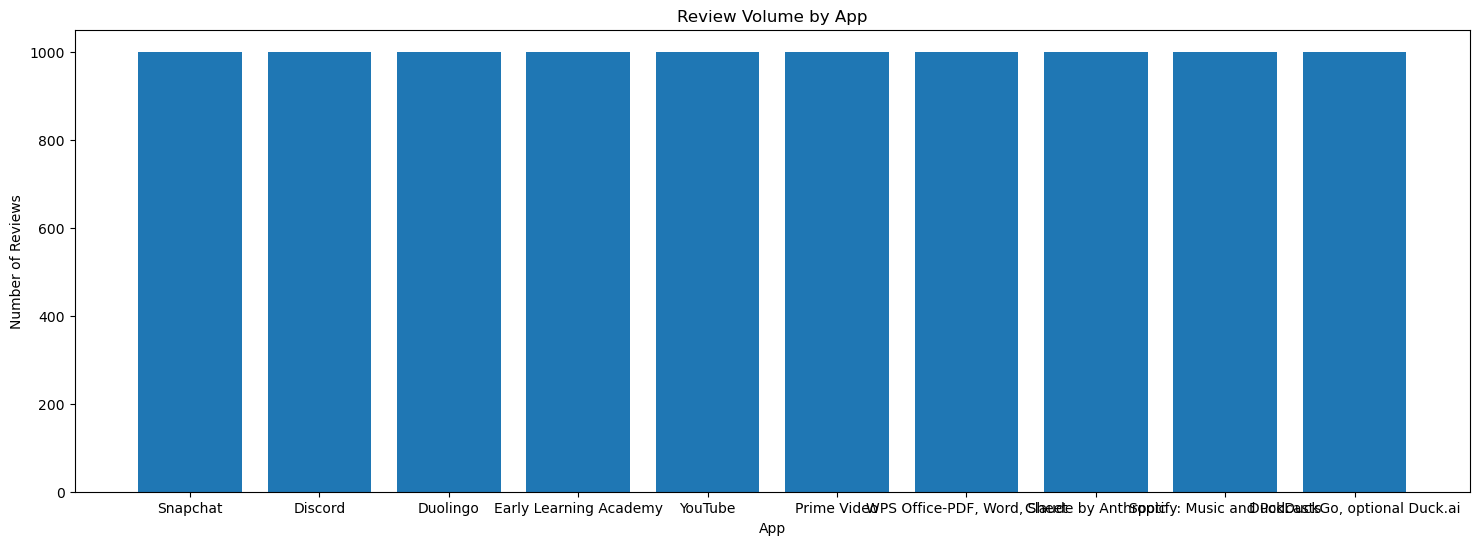

In [141]:
import matplotlib.pyplot as plot

# review volume by app
figure, axis = plot.subplots(figsize = (18, 6))
count_data = review_tab["app"].value_counts()

# get the x and y data
apps = count_data.index
frequencies = count_data.values
axis.bar(apps, frequencies)

axis.set_title("Review Volume by App")
axis.set_xlabel("App")
axis.set_ylabel("Number of Reviews")

plot.show()

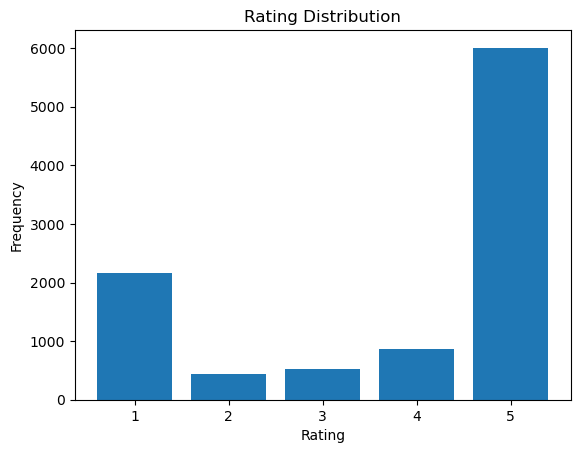

In [143]:
# rating distribution

figure, axis = plot.subplots()
count_data = review_tab["score"].value_counts().sort_index()
ratings = count_data.index
frequencies = count_data.values
axis.bar(ratings, frequencies)
axis.set_title("Rating Distribution")
axis.set_xlabel("Rating")
axis.set_ylabel("Frequency")
plot.show()

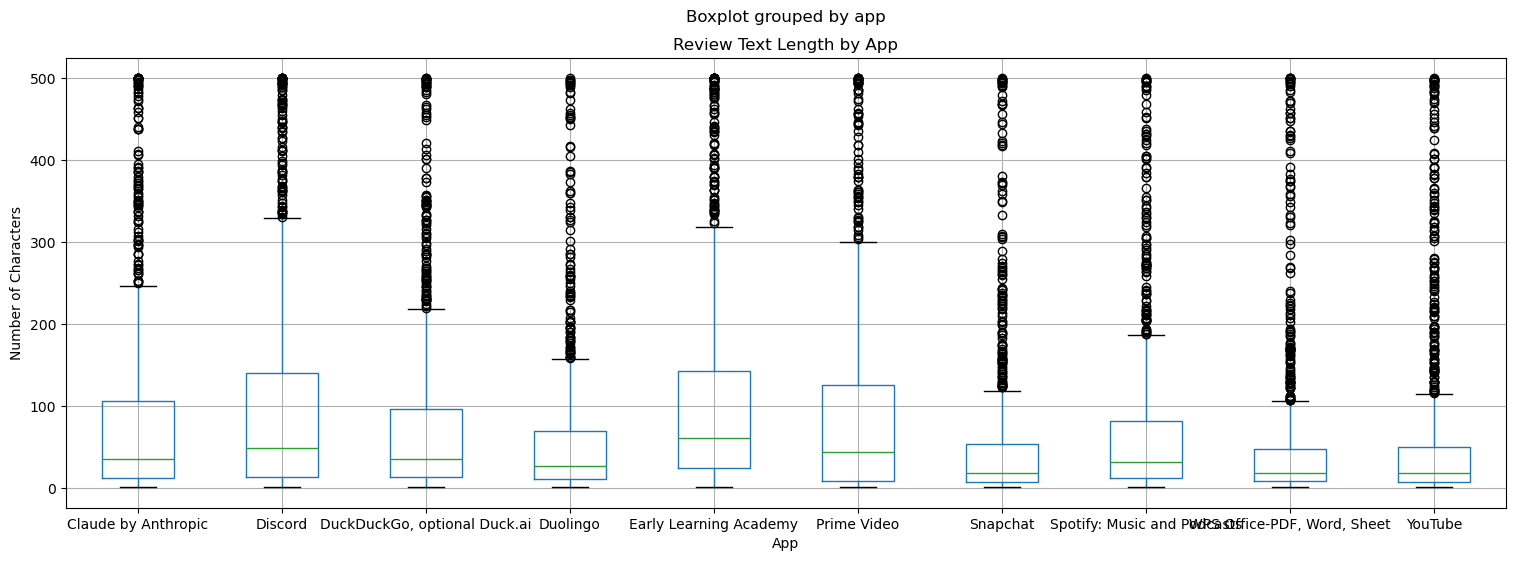

In [147]:
# text length

review_tab["text_length"] = review_tab["content"].str.len()

figure, axis = plot.subplots(figsize = (18, 6))
review_tab.boxplot(column="text_length", by="app", ax=axis)
axis.set_title("Review Text Length by App")
axis.set_xlabel("App")
axis.set_ylabel("Number of Characters")
plot.show()

In [127]:
# timestamp coverage

print("Earliest Review")
display(review_tab.groupby("app")["at"].min())

print("Latest Review")
display(review_tab.groupby("app")["at"].max())

Earliest Review


app
Claude by Anthropic            2026-07-06 04:15:55
Discord                        2026-07-05 22:30:05
DuckDuckGo, optional Duck.ai   2026-06-30 01:18:33
Duolingo                       2026-07-07 07:40:00
Early Learning Academy         2024-01-30 08:26:55
Prime Video                    2026-07-02 07:23:09
Snapchat                       2026-07-09 10:53:42
Spotify: Music and Podcasts    2026-07-11 05:44:53
WPS Office-PDF, Word, Sheet    2026-07-07 16:56:11
YouTube                        2026-07-11 23:50:52
Name: at, dtype: datetime64[ns]

Latest Review


app
Claude by Anthropic            2026-07-12 16:19:14
Discord                        2026-07-12 16:20:51
DuckDuckGo, optional Duck.ai   2026-07-12 16:16:51
Duolingo                       2026-07-12 13:20:13
Early Learning Academy         2026-07-10 12:52:53
Prime Video                    2026-07-12 16:05:56
Snapchat                       2026-07-12 16:21:23
Spotify: Music and Podcasts    2026-07-12 16:24:42
WPS Office-PDF, Word, Sheet    2026-07-12 16:21:08
YouTube                        2026-07-12 16:22:35
Name: at, dtype: datetime64[ns]

In [129]:
# missing fields

missing = pd.DataFrame({
    "Missing Count": review_tab.isnull().sum(),
    "Missing Percentage": (review_tab.isnull().mean()*100).round(2)
})
missing

,Missing Count,Missing Percentage
reviewId,0,0.00
userName,0,0.00
userImage,0,0.00
content,0,0.00
score,0,0.00
thumbsUpCount,0,0.00
reviewCreatedVersion,1602,16.02
at,0,0.00
replyContent,8514,85.14
repliedAt,8514,85.14


In [131]:
# duplicate review IDs

review_tab["reviewId"].duplicated().sum()

0

In [149]:
# repeated review text

# convert review text to lowercase
review_tab["content_lower"] = review_tab["content"].str.lower().str.strip()

# Number of repeated review texts
duplicate_count = review_tab["content_lower"].duplicated().sum()
print(duplicate_count)

# Repeated review texts
duplicate_text = review_tab[review_tab["content_lower"].duplicated()][["app", "content"]]

# Most common repeated review texts
duplicate_textCount = review_tab["content_lower"].value_counts()
duplicate_textCount = duplicate_textCount[duplicate_textCount > 1]
duplicate_textCount.head(10)

1892


content_lower
good         448
nice         128
excellent     84
very good     79
best          62
great         60
good app      54
love it       43
ok            43
good 👍        40
Name: count, dtype: int64

In [135]:
# low-signal reviews

low_signal = review_tab[review_tab["text_length"] < 10]
len(low_signal)
len(low_signal) / len(review_tab) * 100
low_signal["content"].head(20)

0      nice app
15          wow
16     nice 👍🙂🙂
17            💯
20         good
29    bhut acha
32     best app
33    so good 😊
35         good
37            👍
51    very nice
59    pathetic.
60         nice
64        osome
67      bad app
70           ok
76    very hang
79        sweet
80    excellent
81           ok
Name: content, dtype: object

In [137]:
# language
all_reviews_other = []

for app_name, app_id in apps_dict.items():
    result, continuation_token = reviews(
        app_id,
        lang="es",
        country="es",
        sort=Sort.NEWEST,
        count=100
    )

    df = pd.DataFrame(result)

    df["app"] = app_name
    df["language_setting"] = "Spanish"

    all_reviews_other.append(df)

    print(app_name, len(df))

review_other_tab = pd.concat(
    all_reviews_other,
    ignore_index=True
)

review_other_tab.head(20)

Snapchat 100
Discord 100
Duolingo 100
Early Learning Academy 100
YouTube 100
Prime Video 100
WPS Office-PDF, Word, Sheet 100
Claude by Anthropic 100
Spotify: Music and Podcasts 100
DuckDuckGo, optional Duck.ai 100


/var/folders/nv/xrryxf0x64n331bjs28qyj2h0000gn/T/ipykernel_2046/487955370.py:22: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  review_other_tab = pd.concat(


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,app,language_setting
0,80d71360-ed15-41e7-a4f2-6613587bc5c4,Daniela Ibañez,https://play-lh.googleusercontent.com/a-/ALV-U...,"Tiene unos buenos filtros, buenos para mis videos",5,0,None,2026-07-12 15:23:02,None,NaT,None,Snapchat,Spanish
1,e61d36fd-f90a-4baf-8910-e78f4d2f5931,Alba Beriguete,https://play-lh.googleusercontent.com/a/ACg8oc...,excelente,5,0,14.13.0.45,2026-07-12 13:13:22,None,NaT,14.13.0.45,Snapchat,Spanish
2,cafa0d08-4621-4d87-9a4e-b235287d4744,Anto Moreno,https://play-lh.googleusercontent.com/a/ACg8oc...,🤘🤘🤘🤘,5,0,None,2026-07-12 13:04:45,None,NaT,None,Snapchat,Spanish
3,3f89ef46-0f70-40aa-a18c-0d78af5f04ff,Brayhan Perez,https://play-lh.googleusercontent.com/a/ACg8oc...,me gusta por q te deja ver los vídeos asta sin...,5,0,None,2026-07-12 12:44:06,None,NaT,None,Snapchat,Spanish
4,7cd5ca40-f73a-48d7-8c8f-b25a3f71d988,Nayeli Rubio Hernández,https://play-lh.googleusercontent.com/a-/ALV-U...,solo para ver los estados de haaland 🗿,4,0,None,2026-07-12 12:37:31,None,NaT,None,Snapchat,Spanish
5,b2fb5c1b-e762-4b00-9397-974a1bc94e82,VICTORIA LOZANO CASTRO,https://play-lh.googleusercontent.com/a/ACg8oc...,lo Amoooooooooooo oooooooo,5,0,None,2026-07-12 12:31:48,None,NaT,None,Snapchat,Spanish
6,77624bdc-2cc4-42af-9ab9-8703a81f4749,Guadalupe Abarca,https://play-lh.googleusercontent.com/a/ACg8oc...,le doy cinco estrellas porque ya soy famoso en...,5,0,14.13.0.45,2026-07-12 11:48:14,None,NaT,14.13.0.45,Snapchat,Spanish
7,1fbde73b-dc22-4092-9892-8977e7cafc57,Mireya Como chavez,https://play-lh.googleusercontent.com/a/ACg8oc...,Me encanta no tiene casi lag es bonito puedes ...,5,0,14.13.0.45,2026-07-12 11:19:03,None,NaT,14.13.0.45,Snapchat,Spanish
8,97a655e4-98b5-484c-a797-6c9da628b581,Jose Aguirre,https://play-lh.googleusercontent.com/a/ACg8oc...,es muy divertido pero sin son menor de edad y ...,4,0,14.14.0.43,2026-07-12 10:19:55,None,NaT,14.14.0.43,Snapchat,Spanish
9,0006b273-2c28-4202-9291-5107eece8705,Belén Salavarria,https://play-lh.googleusercontent.com/a-/ALV-U...,me voy a descargar esto por Haaland,4,1,None,2026-07-12 09:48:53,None,NaT,None,Snapchat,Spanish
